# BART Project - Data Analysis

In this project, we analyze BART station activities and seek answers on several issues:

Data Analytics Questions
* Which BART station is the busiest?
* What is the least popular BART route?
* When is the best time to go to SF from Berkeley if you want to find a seat?
* Which day of the week is the busiest?
* How many people take the BART late at night?

Data Science Questions
* Question A: Compute the straight line distance between every station
* Question B: Build a model that can predict the number of people commuting to work by Bart between any 2 stations:
* How would you approach that?
* What additional data would you need?
* How would you want the city or Bart officials to use your data? 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bart-ridership/date-hour-soo-dest-2016.csv
/kaggle/input/bart-ridership/station_info.csv
/kaggle/input/bart-ridership/date-hour-soo-dest-2017.csv


In [2]:
a = pd.read_csv('/kaggle/input/bart-ridership/date-hour-soo-dest-2016.csv')
b = pd.read_csv('/kaggle/input/bart-ridership/date-hour-soo-dest-2017.csv')
info = pd.read_csv('/kaggle/input/bart-ridership/station_info.csv')

In [3]:
info

,Abbreviation,Description,Location,Name
0,12TH,"1245 Broadway, Oakland CA 94612<br />12th St. ...","-122.271450,37.803768,0",12th St. Oakland City Center (12TH)
1,16TH,"2000 Mission Street, San Francisco CA 94110<br...","-122.419694,37.765062,0",16th St. Mission (16TH)
2,19TH,"1900 Broadway, Oakland CA 94612<br />19th Stre...","-122.268602,37.808350,0",19th St. Oakland (19TH)
3,24TH,"2800 Mission Street, San Francisco CA 94110<br...","-122.418143,37.752470,0",24th St. Mission (24TH)
4,ASHB,"3100 Adeline Street, Berkeley CA 94703<br />As...","-122.270062,37.852803,0",Ashby (ASHB)
5,BALB,"401 Geneva Avenue, San Francisco CA 94112<br /...","-122.447506,37.721585,0",Balboa Park (BALB)
6,BAYF,"15242 Hesperian Blvd., San Leandro CA 94578<br...","-122.126514,37.696924,0",Bay Fair (BAYF)
7,CAST,"3301 Norbridge Dr., Castro Valley CA 94546<br ...","-122.075602,37.690746,0",Castro Valley (CAST)
8,CIVC,"1150 Market Street, San Francisco CA 94102<br ...","-122.414123,37.779732,0",Civic Center/UN Plaza (CIVC)
9,COLS,"7200 San Leandro St., Oakland CA 94621<br />We...","-122.196869,37.753661,0",Coliseum/Oakland Airport (COLS)


In [4]:
a.head()

,Origin,Destination,Throughput,DateTime
0,12TH,12TH,1,2016-01-01 00:00:00
1,12TH,16TH,1,2016-01-01 00:00:00
2,12TH,24TH,4,2016-01-01 00:00:00
3,12TH,ASHB,4,2016-01-01 00:00:00
4,12TH,BALB,2,2016-01-01 00:00:00


In [5]:
a.shape

(9971582, 4)

In [6]:
b.head()

,Origin,Destination,Throughput,DateTime
0,12TH,19TH,1,2017-01-01 00:00:00
1,12TH,24TH,2,2017-01-01 00:00:00
2,12TH,BAYF,1,2017-01-01 00:00:00
3,12TH,CIVC,5,2017-01-01 00:00:00
4,12TH,COLS,2,2017-01-01 00:00:00


In [7]:
# First, we will merge two files:

df=pd.concat([a,b], ignore_index=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13285207 entries, 0 to 13285206
Data columns (total 4 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   Origin       object
 1   Destination  object
 2   Throughput   int64 
 3   DateTime     object
dtypes: int64(1), object(3)
memory usage: 405.4+ MB


In [9]:
# We convert datetime 

df['DateTime'] = pd.to_datetime(df['DateTime'])

In [10]:
df['DateTime'].sample(5)

3254985    2016-04-29 06:00:00
7191908    2016-09-20 13:00:00
5333821    2016-07-13 21:00:00
10762567   2017-01-31 11:00:00
1557576    2016-02-27 08:00:00
Name: DateTime, dtype: datetime64[ns]

## Data Analytics Questions

### 1. Question: Which BART station is the busiest❓

To find this out, we will investigate the number of people present at the first and last stop for each station.

In [11]:
# Lets not do this one by one:


stations_list = pd.unique(df[['Origin', 'Destination']].values.ravel())


dict_={}
def stations(station):
    summary=df[df.Origin == station]["Throughput"].sum() + df[df.Destination == station]["Throughput"].sum()
    dict_[station]=summary


for station in stations_list:
    stations(station)
    
    

In [12]:
import pprint
pprint.pprint(sorted(dict_.items(), key=lambda x: x[1], reverse=True)[:5])

[('EMBR', 34076644),
 ('MONT', 33063895),
 ('POWL', 26593039),
 ('CIVC', 19536703),
 ('DBRK', 10806360)]


### ✅ So the answer is: EMBR station is the busiest!

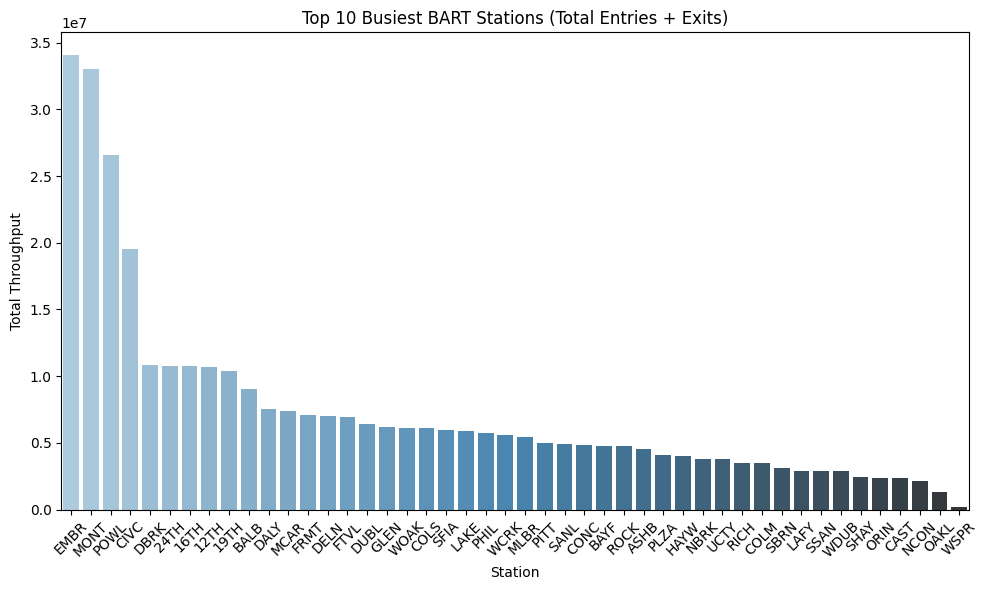

In [13]:
# Visualizing

import pandas as pd

df_vis = pd.DataFrame.from_dict(dict_, orient='index', columns=['Total_Throughput'])
df_vis = df_vis.sort_values('Total_Throughput', ascending=False)


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x=df_vis.index, y='Total_Throughput', data=df_vis, palette='Blues_d')
plt.title('Top 10 Busiest BART Stations (Total Entries + Exits)')
plt.xlabel('Station')
plt.ylabel('Total Throughput')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2. Question: What is the least popular BART route❓

Since it is called "route", we will consider the stations in pairs here.

In [14]:
#We use groupby

route_counts = df.groupby(['Origin', 'Destination'])['Throughput'].sum().reset_index()

In [15]:
least_routes=route_counts.sort_values('Throughput', ascending=True).head(10)

print(least_routes)

     Origin Destination  Throughput
2107   WSPR        SBRN          40
1885   SSAN        WSPR          41
2094   WSPR        MLBR          42
1747   SBRN        WSPR          43
1149   MLBR        WSPR          45
2110   WSPR        SSAN          52
459    COLM        WSPR          54
2079   WSPR        COLM          55
1379   ORIN        WSPR          96
2091   WSPR        LAFY         104


### ✅ So the answer is: WSPR - SBRN Route is the Least Popular!

In [16]:
least_routes['Route'] = least_routes['Origin'] + ' → ' + least_routes['Destination']

/tmp/ipykernel_13/988352201.py:8: UserWarning: Glyph 128647 (\N{METRO}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128647 (\N{METRO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


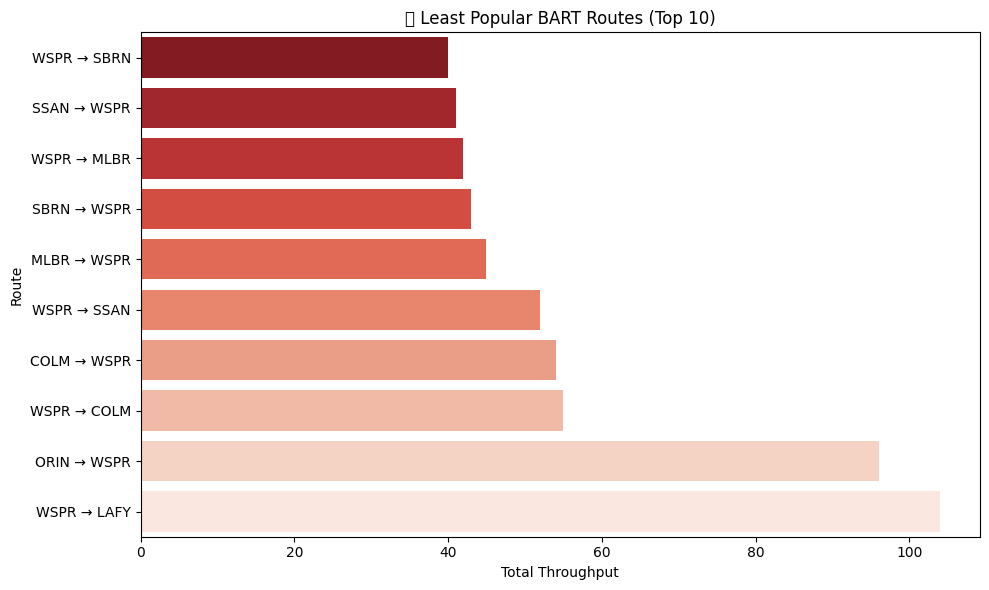

In [17]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Throughput', y='Route', data=least_routes, palette='Reds_r')
plt.title('🚇 Least Popular BART Routes (Top 10)')
plt.xlabel('Total Throughput')
plt.ylabel('Route')
plt.tight_layout()
plt.show()


### 3. Question: When is the best time to go to SF from Berkeley if you want to find a seat❓

To find this out, we need to compare the times and passenger numbers of trips with this route.

In [18]:
berkeley_stations = ['NBRK', 'DBRK', 'ASHB']
sf_stations = ['EMBR', 'MONT', 'POWL', 'CIVC']

route_df = df[(df['Origin'].isin(berkeley_stations)) & (df['Destination'].isin(sf_stations))]

In [19]:
route_df

,Origin,Destination,Throughput,DateTime
136,ASHB,CIVC,2,2016-01-01 00:00:00
140,ASHB,EMBR,1,2016-01-01 00:00:00
143,ASHB,MONT,1,2016-01-01 00:00:00
291,DBRK,MONT,10,2016-01-01 00:00:00
295,DBRK,POWL,1,2016-01-01 00:00:00
...,...,...,...,...
13284559,DBRK,EMBR,8,2017-05-03 23:00:00
13284568,DBRK,MONT,5,2017-05-03 23:00:00
13284572,DBRK,POWL,9,2017-05-03 23:00:00
13284894,NBRK,EMBR,1,2017-05-03 23:00:00


In [20]:
route_df = df[(df['Origin'].isin(berkeley_stations)) & (df['Destination'].isin(sf_stations))].copy()
route_df['DateTime'] = pd.to_datetime(route_df['DateTime'])
route_df['hour'] = route_df['DateTime'].dt.hour

In [21]:
hourly_avg = route_df.groupby('hour')['Throughput'].mean().reset_index()

In [22]:
hourly_avg.sort_values(by='Throughput', ascending=True)


,hour,Throughput
4,4,1.663054
1,1,2.469291
3,3,2.538462
2,2,2.809524
0,0,4.498166
5,5,6.283342
23,23,7.092208
22,22,8.900325
21,21,9.472084
20,20,11.087713


### ✅  So the answer is: The highest probability of finding a seat is at 4 am! 

/tmp/ipykernel_13/1783196331.py:7: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


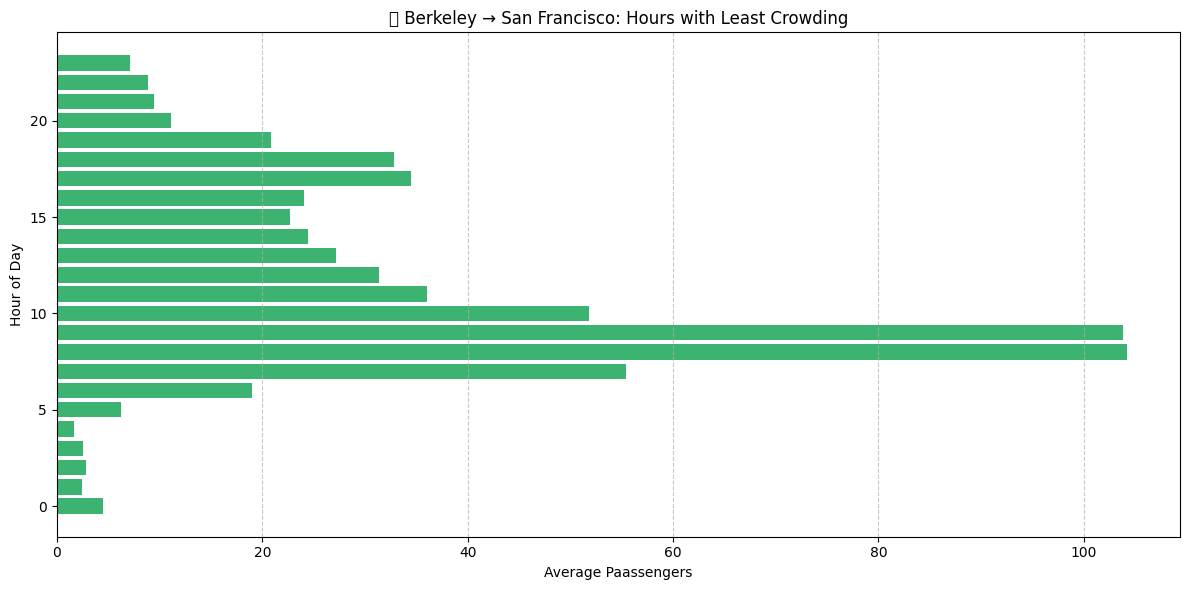

In [23]:

plt.figure(figsize=(12, 6))
plt.barh(hourly_avg['hour'], hourly_avg['Throughput'], color='mediumseagreen')
plt.title('🟢 Berkeley → San Francisco: Hours with Least Crowding')
plt.xlabel('Average Paassengers')
plt.ylabel('Hour of Day')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 4. Question: Which day of the week is the busiest❓

Now, we'll compare it across days. We'll calculate the number of passengers for all trips on a single day of the week and compare it to other days.

In [24]:
days_df = df[['Throughput', 'DateTime']].copy()
days_df['DateTime'] = pd.to_datetime(days_df['DateTime'])
days_df['Weekday'] = days_df['DateTime'].dt.day_name()

In [25]:
days=days_df.groupby("Weekday")["Throughput"].sum().reset_index()
days.sort_values(by="Throughput", ascending=False)

,Weekday,Throughput
6,Wednesday,30677189
5,Tuesday,30350159
4,Thursday,30049974
0,Friday,28373709
1,Monday,26967803
2,Saturday,13696288
3,Sunday,9602140


### ✅ So the answer is: Wednesday is the busiest weekday!

/tmp/ipykernel_13/729924767.py:6: UserWarning: Glyph 128647 (\N{METRO}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128647 (\N{METRO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


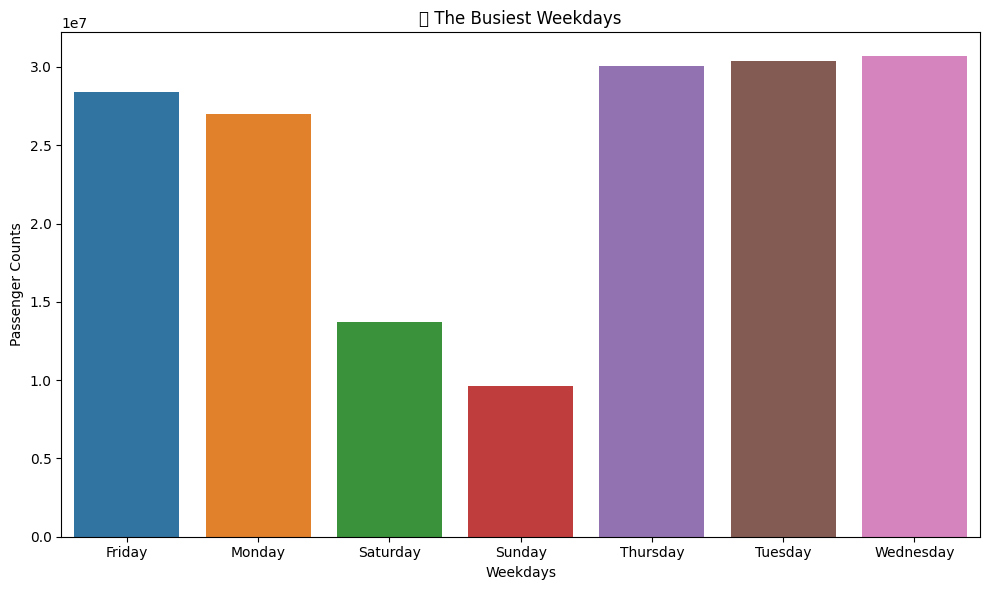

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Weekday', y='Throughput', data=days)
plt.title('🚇 The Busiest Weekdays')
plt.xlabel('Weekdays')
plt.ylabel('Passenger Counts')
plt.tight_layout()
plt.show()

### 5. Question: How many people take the BART late at night❓

To do this, we first need to specify exactly what hours we should take with "late night"

00:00–04:59 -> 🌙 Late Night 

In [27]:
hours_df = df[['Throughput', 'DateTime']].copy()
hours_df['DateTime'] = pd.to_datetime(hours_df['DateTime'])
hours_df['Hours'] = hours_df['DateTime'].dt.hour

In [28]:
filtered = hours_df[(hours_df["Hours"] >= 0) & (hours_df["Hours"] <= 4)]

In [29]:
sum_=filtered["Throughput"].sum()

In [30]:
sum_

2085357

### ✅ So the answer is: A total of 2,085,357 people travel during the night hours on BART!

## Data Science Questions

### Question A: Compute the straight line distance between every station

In [31]:
# we import some libraries (i get this from chatGPT)
from geopy.distance import geodesic
import itertools

station_pairs = list(itertools.combinations(info['Abbreviation'], 2))

In [32]:
info[['longitude', 'latitude', 'elevation']] = info['Location'].str.split(',', expand=True).astype(float)

In [33]:
distances = []

for a, b in station_pairs:
    coord_a = tuple(info[info['Abbreviation'] == a][['latitude', 'longitude']].values[0])
    coord_b = tuple(info[info['Abbreviation'] == b][['latitude', 'longitude']].values[0])
    distance_km = geodesic(coord_a, coord_b).kilometers

    distances.append({'Station_A': a, 'Station_B': b, 'Distance_km': distance_km})

In [34]:
distance_df = pd.DataFrame(distances)
distance_df

,Station_A,Station_B,Distance_km
0,12TH,16TH,13.747174
1,12TH,19TH,0.567050
2,12TH,24TH,14.121801
3,12TH,ASHB,5.443925
4,12TH,BALB,17.996157
...,...,...,...
1030,WARM,WDUB,21.951538
1031,WARM,WOAK,45.985559
1032,WCRK,WDUB,25.924283
1033,WCRK,WOAK,22.935683


## Question B: Build a model that can predict the number of people commuting to work by Bart between any 2 stations:
 * How would you approach that?
 * What additional data would you need?
 * How would you want the city or Bart officials to use your data? 

### How would you approach that?
I would build a regression model using historical ridership data. The features would include origin/destination stations, time of day, day of the week, holiday indicators, and route distance. I’d apply models like Random Forest or Gradient Boosting and validate using cross-validation.

### What additional data would you need?
* Public holidays and school schedules

* Local events (concerts, sports, etc.)

* Weather conditions

* Population/employment density near each station

* Real-time train availability or delays

### How would you want the city or BART officials to use your data?
* Optimize train frequency during peak commute hours

* Improve capacity planning and reduce congestion

* Adjust schedules based on real-time demand

* Enhance rider experience and safety

* Plan future expansions or infrastructure investments efficiently